In [20]:
#Import the required packages
#Import package pandas for data analysis
import pandas as pd

# Import package numpy for numeric computing
import numpy as np

# Import package matplotlib for visualisation/plotting
import matplotlib.pyplot as plt

#For showing plots directly in the notebook run the command below
%matplotlib inline

# For saving multiple plots into a single pdf file
from matplotlib.backends.backend_pdf import PdfPages


In [21]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Cleaned.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,County,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonth,Region
0,Wexford,62500.0,No,No,Second-Hand Dwelling house /Apartment,2016,7,NON_DUBLIN
1,Cork,150000.0,Yes,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
2,Wexford,94000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
3,Leitrim,149500.0,No,Yes,New Dwelling house /Apartment,2016,2,NON_DUBLIN
4,Mayo,170000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,NON_DUBLIN
5,Galway,50000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
6,Kildare,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,12,NON_DUBLIN
7,Dublin,15000.0,No,No,Second-Hand Dwelling house /Apartment,2016,10,DUBLIN14
8,Waterford,160000.0,No,No,Second-Hand Dwelling house /Apartment,2016,8,NON_DUBLIN
9,Kilkenny,320000.0,No,Yes,New Dwelling house /Apartment,2016,12,NON_DUBLIN


In [22]:
# check the type of the columns
df.dtypes

County                    object
Price(€)                 float64
NotFullMarketPrice        object
VATExclusive              object
DescriptionofProperty     object
SaleYear                   int64
SaleMonth                  int64
Region                    object
dtype: object

In [23]:
# correct the feature types
for col in df.select_dtypes('object').columns:
    df[col] = df[col].astype('category')
for col in df.select_dtypes('int64').columns:
    df[col] = df[col].astype('category')
df.dtypes

County                   category
Price(€)                  float64
NotFullMarketPrice       category
VATExclusive             category
DescriptionofProperty    category
SaleYear                 category
SaleMonth                category
Region                   category
dtype: object

In [24]:
# Descriptive stats for numeric features only.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price(€),53996.0,280407.849859,166508.296215,5250.0,158000.0,250987.5,365000.0,675500.0


In [25]:
#Look at the categorical features only
category_columns = df.select_dtypes(['category']).columns
category_columns
# Descriptive stats for categorical features only.
df[category_columns].describe().T

,count,unique,top,freq
County,53996,26,Dublin,16678
NotFullMarketPrice,53996,2,No,51170
VATExclusive,53996,2,No,44295
DescriptionofProperty,53996,3,Second-Hand Dwelling house /Apartment,44139
SaleYear,53996,9,2018,6000
SaleMonth,53996,12,12,6347
Region,53996,24,NON_DUBLIN,37318


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\2959089736.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('County')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\2959089736.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


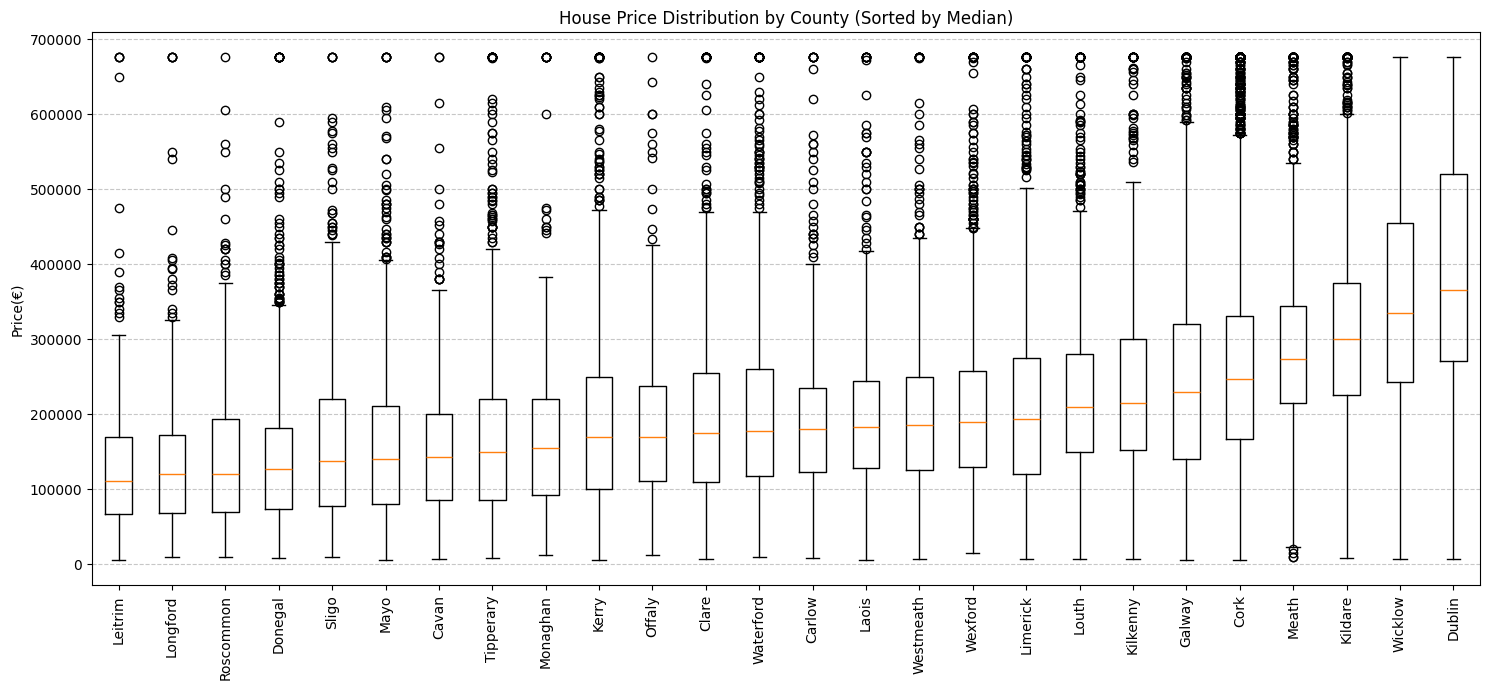

In [28]:
# pair the price with county

# sort by median
grouped = df.groupby('County')['Price(€)'].median().sort_values()

data_to_plot = [df[df['County'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by County (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\1668246194.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('Region')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\1668246194.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


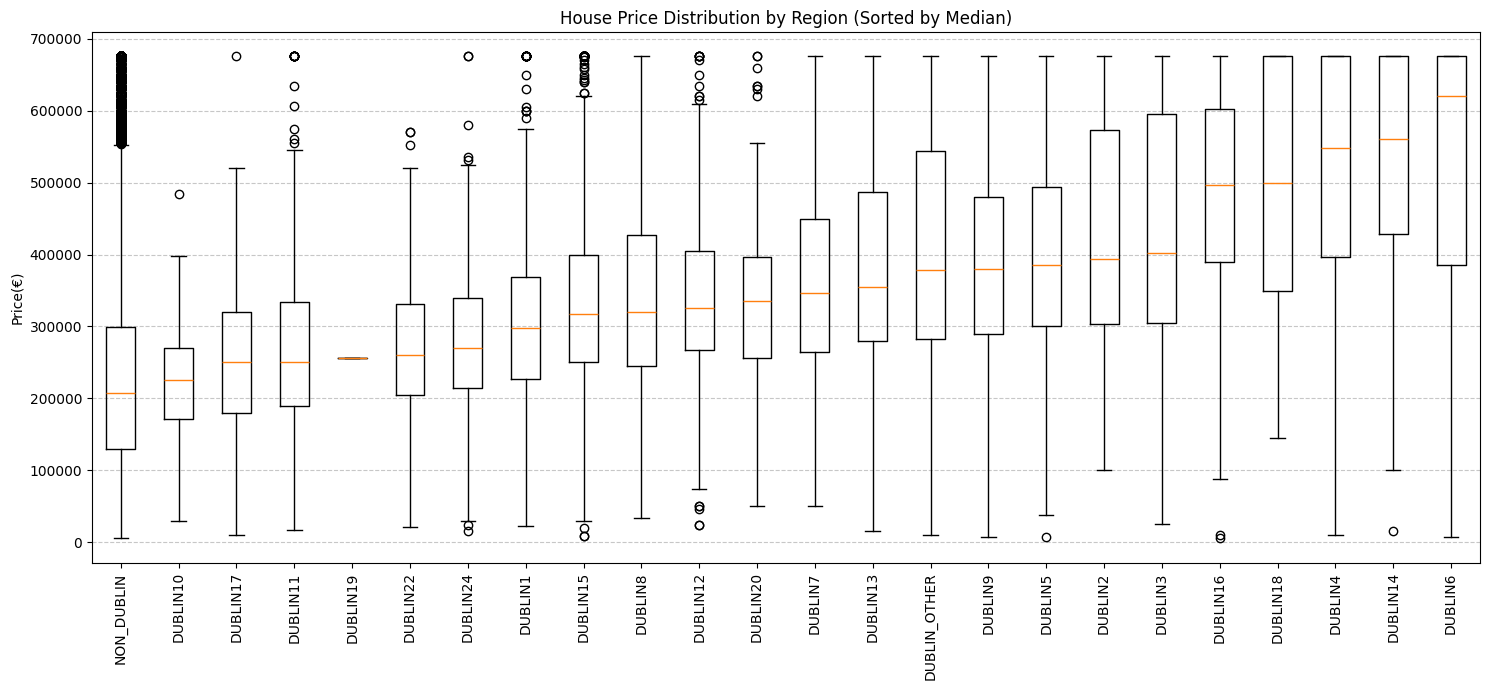

In [29]:
# pair the price with Region

# sort by median
grouped = df.groupby('Region')['Price(€)'].median().sort_values()

data_to_plot = [df[df['Region'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by Region (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\351036637.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleYear')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\351036637.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


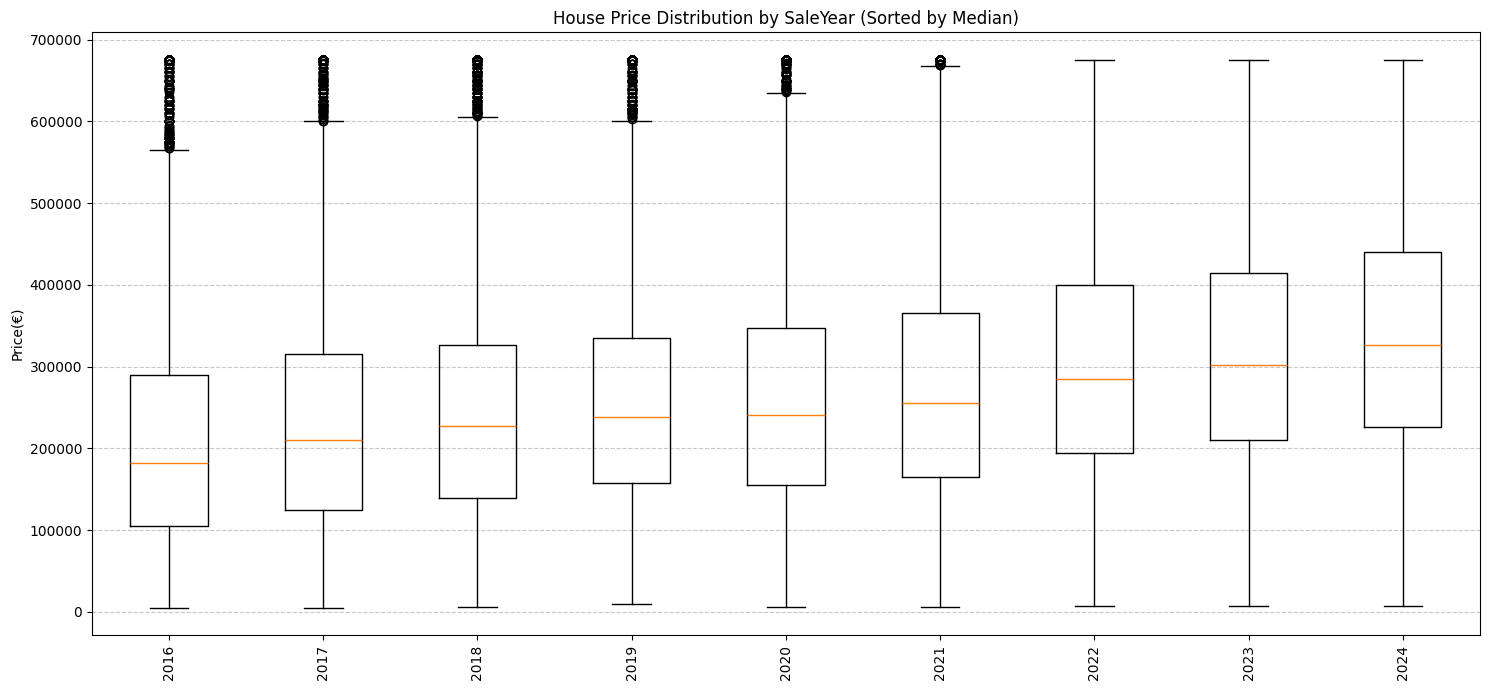

In [ ]:
# pair the price with SaleYear

# sort by median
grouped = df.groupby('SaleYear')['Price(€)'].median().sort_values()

data_to_plot = [df[df['SaleYear'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleYear (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\1763831392.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('SaleMonth')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\1763831392.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


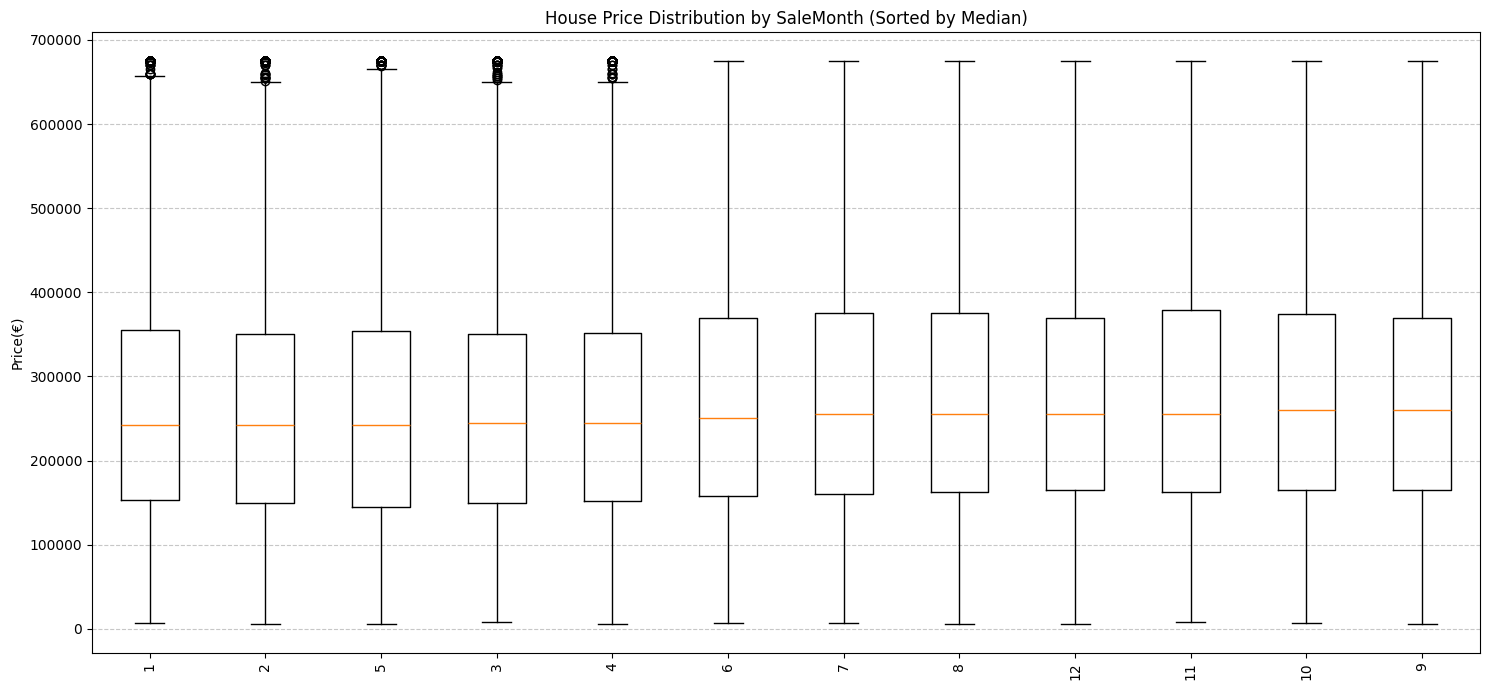

In [32]:
# pair the price with SaleMonth

# sort by median
grouped = df.groupby('SaleMonth')['Price(€)'].median().sort_values()

data_to_plot = [df[df['SaleMonth'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by SaleMonth (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\1596940852.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\1596940852.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


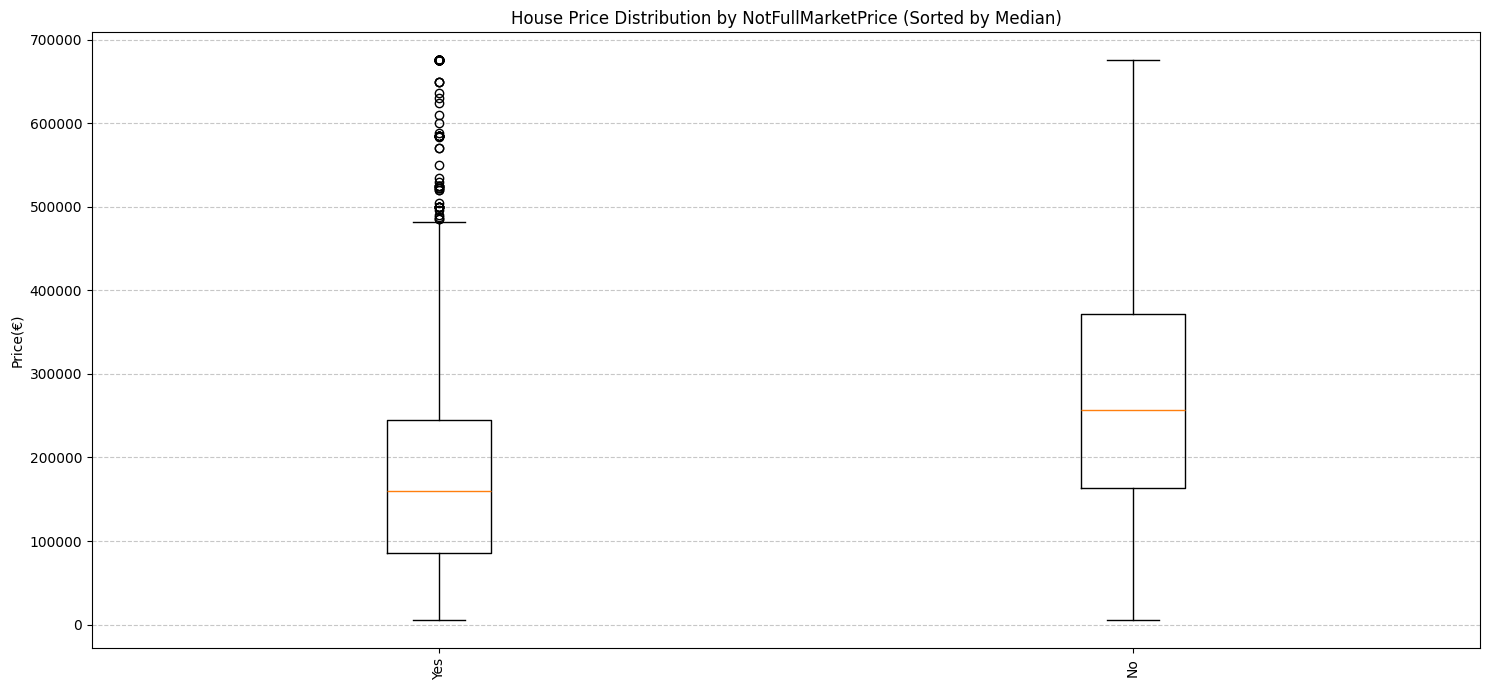

In [33]:
# pair the price with NotFullMarketPrice

# sort by median
grouped = df.groupby('NotFullMarketPrice')['Price(€)'].median().sort_values()

data_to_plot = [df[df['NotFullMarketPrice'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by NotFullMarketPrice (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\3016736474.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\3016736474.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


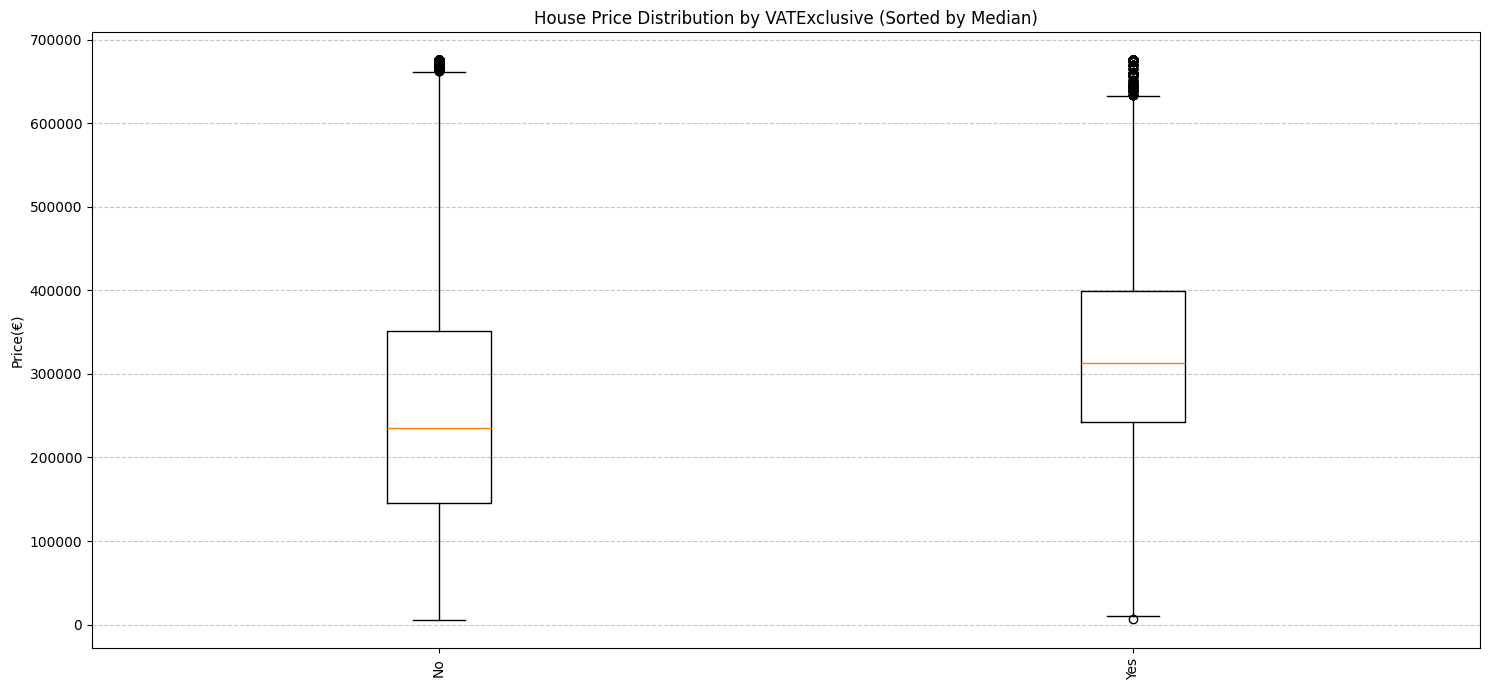

In [ ]:
# pair the price with VATExclusive

# sort by median
grouped = df.groupby('VATExclusive')['Price(€)'].median().sort_values()

data_to_plot = [df[df['VATExclusive'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by VATExclusive (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\2363896353.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34548\2363896353.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=grouped.index)


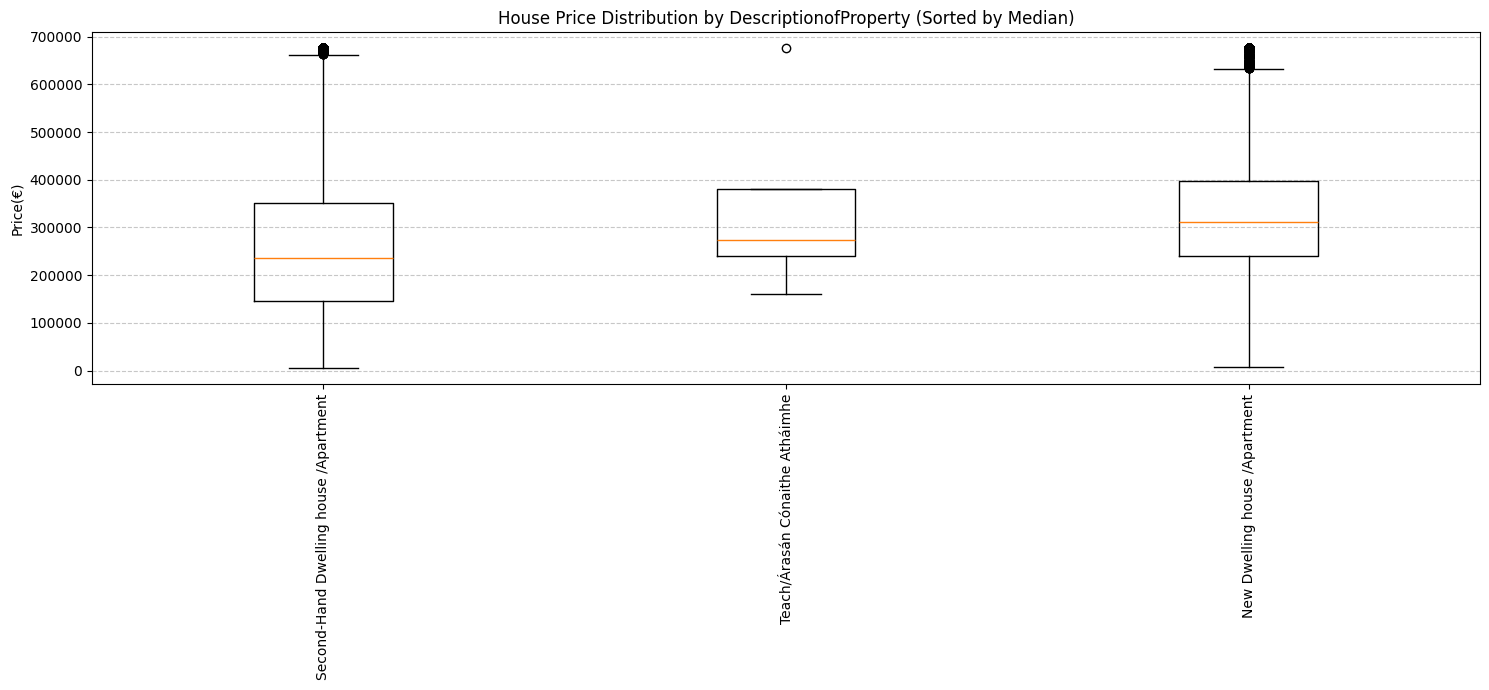

In [35]:
# pair the price with VATExclusive

# sort by median
grouped = df.groupby('DescriptionofProperty')['Price(€)'].median().sort_values()

data_to_plot = [df[df['DescriptionofProperty'] == x]['Price(€)'] for x in grouped.index]


plt.figure(figsize=(15, 7))
plt.boxplot(data_to_plot, labels=grouped.index)

plt.xticks(rotation=90)
plt.ylabel('Price(€)')
plt.title('House Price Distribution by DescriptionofProperty (Sorted by Median)')
plt.grid(axis='y', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

In [37]:
df['DescriptionofProperty'].value_counts()

DescriptionofProperty
Second-Hand Dwelling house /Apartment    44139
New Dwelling house /Apartment             9853
Teach/Árasán Cónaithe Atháimhe               4
Name: count, dtype: int64